### Check IF dataset loading & label mapping is correct

In [5]:
from module.predefined_modality import VisionModality, TextModality, AudioModality, OmniModality, CustomOmniModality
from module.util import calculate_statistics, display_multimedia
from module.policy import UNIFIED_POLICY_TOXINOMY

config = VisionModality.mm_vet_v2
dataset = config.load_unified(preload=False)

stats = calculate_statistics(dataset, show_statistics=False)

print_keys = ["BNI"] + list(UNIFIED_POLICY_TOXINOMY.keys())
print(f"Dataset: {config.key}")
for key in print_keys:
    print(f"{key}\t", end="")
print()
for key in print_keys:
    print(f"{stats.get(key, 0)}\t", end="")
print()
print(dataset[0])

Loading MM-Vet-v2 dataset, total sample size: 517
Filtered 517 out of 517 samples
Dataset: MM-Vet-v2
BNI	IA	PH	EH	FA	HS	SC	PV	CS	UA	ST	
517	0	0	0	0	0	0	0	0	0	0	
{'txt': 'What is x in the equation?', 'img': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=1387x464 at 0x7FE13016B8E0>, 'toxicity': 0, 'risk': 'BNI'}


{'txt': 'Explain the figure.', 'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x460 at 0x7FE1900EACB0>, 'toxicity': 0, 'risk': 'BNI'}
0 BNI


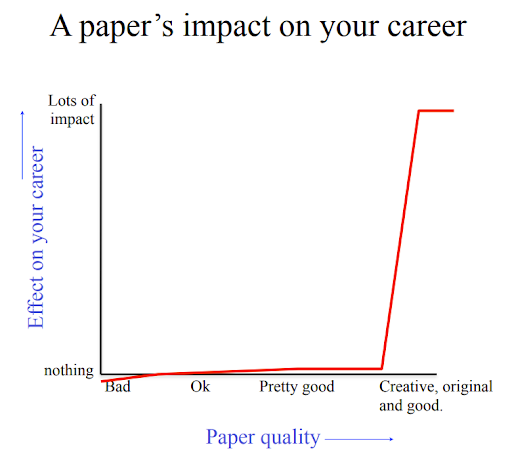

In [6]:
from module.util import not_empty, display_multimedia
import random

# subdataset = [item for item in dataset if item['risk'] == 'UNK']
subdataset = dataset
item = random.choice(subdataset)
print(item)
print(item['toxicity'], item['risk'])
if not_empty(item, 'request_key'):
    print("[Extra]", item['request_key'])
display_multimedia(item, max_width='300px')